In [1]:
# ==========================================
# 1. Standard Library & Basic Imports
# ==========================================
import os
import re
import json
import asyncio
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import praw
import ast
import chromadb
import random
import nest_asyncio
import operator

# ==========================================
# 2. From Imports (Specific Modules)
# ==========================================

from dotenv import load_dotenv
from typing import Annotated, List, TypedDict
from datetime import datetime
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

from openai import AsyncOpenAI

import chromadb
from chromadb.utils import embedding_functions
from langchain_community.vectorstores import Chroma

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode

nest_asyncio.apply()
load_dotenv()

c:\Users\108\Documents\연구 관련\MS_RESEARCH\MS_Proj\MS_Proj_Env\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# ==========================================
# 3. Environment Setting
# ==========================================

# Reddit
client_id     = os.getenv("CLIENT_ID")
client_secret = os.getenv("CLIENT_SECRET")
user_agent    = os.getenv("USER_AGENT")

reddit = praw.Reddit(
    client_id     = client_id,
    client_secret = client_secret,
    user_agent    = user_agent
)

# LLM 모델
llm = ChatOpenAI(
    model        = "gpt-5.1",
    model_kwargs = {"service_tier": "flex"},
    temperature  = 0,
    api_key      = os.getenv("OPENAI_API_KEY"),
    response_format = {"type": "json_object"}
)

# 임베딩 모델
embeddings = OpenAIEmbeddings()

# ── 변경: ChromaDB를 Purpose별로 분리 ──
# 기존: 단일 컬렉션 → Professional/Casual CR이 섞여 RAG 오염
# 변경: Purpose마다 독립 컬렉션 → 세그먼트별 RAG 정확도 향상
PURPOSES   = ["Professional", "Casual"]
BATCH_SIZE = 50  # 한 번에 LLM에 전달할 리뷰 수

vector_dbs = {
    purpose: Chroma(
        collection_name    = f"cr_{purpose.lower()}",
        embedding_function = embeddings,
        persist_directory  = f"./chroma_db_{purpose.lower()}"
    )
    for purpose in PURPOSES
}

c:\Users\108\Documents\연구 관련\MS_RESEARCH\MS_Proj\MS_Proj_Env\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3641: UserWarning: WARNING! response_format is not default parameter.
                response_format was transferred to model_kwargs.
                Please confirm that response_format is what you intended.
  if await self.run_code(code, result, async_=asy):
c:\Users\108\Documents\연구 관련\MS_RESEARCH\MS_Proj\MS_Proj_Env\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3641: UserWarning: Parameters {'service_tier'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):
C:\Users\108\AppData\Local\Temp\ipykernel_10936\2978441258.py:35: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `

In [3]:
# ==========================================
# 4. Class and Function Definitions
# ==========================================

# ── Phase 1 GraphState: 행별 Tagging (기존과 동일) ──
class TaggingState(TypedDict):
    raw_review:       str
    is_valid:         bool
    primary_purpose:  str
    designer_action:  str
    reasoning:        str
    purpose_signals:  List[str]
    evidence_snippet: str


# ── Phase 2 GraphState: 배치 단위 CR Extraction ──
class ExtractionState(TypedDict):
    purpose:             str
    reviews:             List[str]   # 배치 내 리뷰 목록
    designer_actions:    List[str]   # 배치 내 designer_action 목록
    existing_knowledge:  str         # ChromaDB 조회 결과
    extracted_crs:       List[dict]
    cr_inventory:        Annotated[List[str], operator.add]


# --------------------------------------------------
# [Phase 1] Tagging (기존과 동일)
# --------------------------------------------------
def get_openai_tags(review_text):
    system_instruction = """
        ### Role: Senior NPD Research Data Auditor

        Your sole mission is to determine if a review is "Actionable Product Feedback"
        and classify its usage purpose.

        ## Step 1. Validity Check (is_valid):
        Do NOT look for noise patterns. Instead, ask yourself:

        "Can I complete this sentence from this review?
        'A product designer should [do X] because this user needs [Y].'"

        - If YES → proceed to Step 2
        - If NO  → is_valid: false, primary_purpose: "None", stop here

        A valid review must satisfy ALL of the following:
        1. It is a self-contained statement (not a reply fragment or conversation).
        2. It expresses a concrete preference, expectation, or complaint about
        the product's design, performance, or ergonomics.
        3. A product designer can extract a concrete requirement from it.
        The primary intent is NOT to seek help, ask for recommendations,
        or get answers from other users.

        ## Step 2. Evidence Collection (BEFORE assigning purpose):
        List the specific signals in the review that indicate Professional or Casual intent.

        - You MUST find at least 2 concrete, distinct signals to assign a purpose.
        - If you cannot find 2 signals, set primary_purpose: "None", is_valid: false.

        Signals for **Professional**:
            The laptop is used as a tool for specialized, skill-based work
            where performance directly impacts output quality or productivity.
            (e.g., software dev, data science, 4K editing, 3D rendering,
            heavy corporate multitasking, engineering tools, etc.)

        Signals for **Casual**:
            The laptop is used primarily for consumption, communication,
            or light tasks without domain-specific performance demands.
            (e.g., web browsing, streaming, social media,
            basic student homework, everyday home use, etc.)

        ## Step 3. Confidence Check:
        Ask yourself: "If I read this review 10 times, would I assign
        the same purpose every time with >90% certainty?"

        - If YES → assign the purpose
        - If NO, or if Professional and Casual signals are mixed/equal →
        primary_purpose: "None", is_valid: false

        ## Output Schema (JSON Only):
        Important: Fill in "purpose_signals" BEFORE deciding "primary_purpose".
        {
            "purpose_signals": ["signal 1 from the review", "signal 2 from the review"],
            "is_valid": boolean,
            "primary_purpose": "Professional" | "Casual" | "None",
            "designer_action": "Complete the sentence: 'A designer should [X] because this user needs [Y].' Leave empty string if is_valid is false.",
            "reasoning": "One sentence explaining the validity and purpose decision.",
            "evidence_snippet": "The most relevant quote. Empty string if invalid."
        }
    """
    try:
        response = llm.invoke([
            SystemMessage(content=system_instruction),
            HumanMessage(content=f'Review: "{review_text}"')
        ])
        return response.content
    except Exception as e:
        print(f"Error: {e}")
        return None


def tagging_node(state: TaggingState):
    print(f"\n--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---")
    response_content = get_openai_tags(state["raw_review"])
    try:
        result = json.loads(
            response_content.replace("```json", "").replace("```", "").strip()
        )
        return {
            "is_valid":         result.get("is_valid", False),
            "primary_purpose":  result.get("primary_purpose", "None"),
            "designer_action":  result.get("designer_action", ""),
            "reasoning":        result.get("reasoning", ""),
            "purpose_signals":  result.get("purpose_signals", []),
            "evidence_snippet": result.get("evidence_snippet", "")
        }
    except Exception as e:
        print(f"Tagging 노드 결과 파싱 중 오류 발생: {e}")
        return {
            "is_valid": False, "primary_purpose": "None",
            "designer_action": "", "reasoning": f"JSON Parsing Error: {str(e)}",
            "purpose_signals": [], "evidence_snippet": ""
        }


def should_continue(state: TaggingState):
    return "continue" if state["is_valid"] else "end"


# --------------------------------------------------
# [Phase 2] CR Extraction (배치 방식)
# --------------------------------------------------
def get_cr_extraction_prompt(purpose, existing_knowledge):
    return f"""
        ### Identity: The Voice of the "{purpose}" User Group
        You are the representative of the "{purpose}" community. You understand their
        lifestyle, daily challenges, and the specific performance standards they demand
        from a laptop.

        ### Reference Knowledge (Existing Memory):
        The following terms are already standardized in our database. If the current
        reviews' needs match any of these semantically, you MUST use the exact same
        term to ensure data consistency:
        {existing_knowledge if existing_knowledge else "No existing terms yet."}

        ### Mission:
        Read the following review batch (each review prefixed with [R#]) and extract
        **Atomic Customer Requirements (CR)** representing the collective needs of
        the "{purpose}" segment.

        ### CR Extraction Rules (Strict):
        1. **Segment-Level, Not Review-Level**: Identify COMMON or REPRESENTATIVE needs
        across the batch. Do NOT extract a CR for every single sentence.
        2. **Atomic & Single-Intent**: Each CR must contain only ONE specific need.
        If a review mentions weight and battery, split into two separate CRs.
        3. **CR Naming Style**: Follow the naming rules defined below.
        4. **Exclude Reasons & Context**: Put all supporting context in evidence_summary.
        5. **Objective Translation**: Convert subjective feedback into objective standards.
        6. **Term Consistency (CRITICAL)**: Prioritize mapping to Reference Knowledge
        before creating a new term.
        7. **Minimum Evidence Threshold**: Only extract a CR if it is mentioned by
        AT LEAST 2 different reviews in the batch. A need raised by only one review
        is NOT sufficient to be a CR unless it is a uniquely critical requirement
        that other reviews implicitly support.
        8. **Count Limit**: Extract a MAXIMUM of 8 CRs per batch. If you find more,
        keep only the 8 most representative and frequently mentioned ones.
        9. **Zero CR is acceptable**: If reviews in the batch are too vague or contain
        no actionable requirement, do NOT force a CR. Extracting 0 CRs is perfectly fine.
        10. **Deduplication**: If multiple reviews mention the same need,
            consolidate into ONE CR with aggregated evidence.

        ### CR Naming Style: [Direction adjective] + [Attribute noun] (+ optional spec)
        The CR must convey WHAT the user wants AND in WHICH DIRECTION.
        A bare attribute name like "Battery life" or "Weight" is NOT acceptable
        because it carries no directional meaning for QFD scoring.

        ### Examples:
        - ❌ Too vague:    "Battery life"
        (which direction? longer? more stable?)
        - ❌ Too verbose:  "Long battery life for all-day mobile work"
        (reasons belong in evidence_summary, not the CR label)
        - ✅ Good:         "Extended battery life"
        - ✅ Good:         "Battery life (all-day)"

        - ❌ Too vague:    "Weight"
        - ❌ Too verbose:  "Lightweight chassis under 1.5kg for portability during commute"
        - ✅ Good:         "Reduced chassis weight"
        - ✅ Good:         "Body weight (under 1.5kg)"

        - ❌ Too vague:    "Display"
        - ❌ Planner lang: "Appropriate and clearly communicated display aspect ratio"
        - ✅ Good:         "High display resolution"
        - ✅ Good:         "Display color accuracy (DCI-P3 coverage)"

        - ❌ Too vague:    "Thermal management"
        - ❌ Comparative:  "Quiet thermals rivaling MacBook"
        - ✅ Good:         "Stable thermal performance under sustained load"
        - ✅ Good:         "Low fan noise during operation"

        ### Additional Rules for CR Labels:
        - NO comparative expressions (e.g., "rivaling MacBook", "Mac-like")
        - NO reasons or context (e.g., "for commuting", "for heavy typing")
        - NO planner/marketer language (e.g., "product positioning", "clearly communicated")

        ### Output Schema (JSON only):
        {{
            "representative_persona": "Brief identity as a {purpose} user",
            "requirements": [
                {{
                    "requirement": "Direction + Attribute noun-phrase (e.g., 'Extended battery life', 'Low fan noise')",
                    "is_mapped_from_memory": false,
                    "supporting_reviews": ["R1", "R3"],
                    "evidence_summary": "Short aggregated summary of what users said"
                }}
            ]
        }}
    """


def rag_node(state: ExtractionState):
    """Purpose별 ChromaDB에서 기존 CR을 검색합니다."""
    purpose    = state["purpose"]
    reviews    = state["reviews"]
    db         = vector_dbs[purpose]
    batch_text = " ".join(reviews[:10])
    try:
        related_docs = db.similarity_search(batch_text, k=7)
        existing     = "\n".join([f"- {doc.page_content}" for doc in related_docs])
    except Exception as e:
        print(f"Chroma DB 검색 중 알림: {e}")
        existing = ""
    return {"existing_knowledge": existing}


def extraction_node(state: ExtractionState):
    """배치 내 리뷰 전체를 한 번에 받아 세그먼트 수준 CR을 추출합니다."""
    purpose            = state["purpose"]
    reviews            = state["reviews"]
    designer_actions   = state["designer_actions"]
    existing_knowledge = state["existing_knowledge"]

    print(f"--- [에이전트: Extractor] {purpose} / {len(reviews)}개 리뷰 배치 분석 ---")

    numbered_reviews = "\n\n".join([f"[R{i+1}] {r}" for i, r in enumerate(reviews)])
    actions_summary  = "\n".join([f"- {a}" for a in designer_actions if a])

    system_prompt = get_cr_extraction_prompt(purpose, existing_knowledge)
    user_prompt   = (
        f"### Design Guidance Summary:\n{actions_summary}\n\n"
        f"### Reviews to Analyze ({len(reviews)} reviews):\n{numbered_reviews}"
    )

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ])
        content = response.content.replace("```json", "").replace("```", "").strip()
        result  = json.loads(content)

        new_requirements = result.get("requirements", [])

        # 신규 CR만 Purpose별 ChromaDB에 저장
        new_terms = [
            req["requirement"]
            for req in new_requirements
            if not req.get("is_mapped_from_memory", True)
        ]
        if new_terms:
            vector_dbs[purpose].add_texts(
                new_terms,
                metadatas=[{"purpose": purpose}] * len(new_terms)
            )
            print(f">>> [Memory/{purpose}] {len(new_terms)}개 신규 CR 등록")

        return {
            "extracted_crs": new_requirements,
            "cr_inventory":  [req["requirement"] for req in new_requirements]
        }

    except Exception as e:
        print(f"Extraction 노드 오류 ({purpose}): {e}")
        return {"extracted_crs": []}

In [4]:
# ==========================================
# 5. Workflow Construction
# ==========================================

# ── Phase 1 Workflow: Tagging (행별, 기존과 동일) ──
tagging_workflow = StateGraph(TaggingState)
tagging_workflow.add_node("Tagger", tagging_node)
tagging_workflow.set_entry_point("Tagger")
tagging_workflow.add_conditional_edges(
    "Tagger",
    should_continue,
    {"continue": END, "end": END}
)
tagging_app = tagging_workflow.compile()

# ── Phase 2 Workflow: CR Extraction (배치, RAG → Extraction) ──
extraction_workflow = StateGraph(ExtractionState)
extraction_workflow.add_node("RAG",        rag_node)
extraction_workflow.add_node("Extraction", extraction_node)
extraction_workflow.set_entry_point("RAG")
extraction_workflow.add_edge("RAG", "Extraction")
extraction_workflow.add_edge("Extraction", END)
extraction_app = extraction_workflow.compile()

In [ ]:
raw_data = pd.read_excel('../Data/raw_data/reddit_reviews_03.xlsx')
raw_data = raw_data[:5000]
raw_data.shape

(5000, 5)

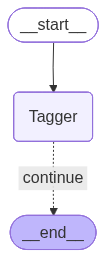

In [6]:
tagging_app

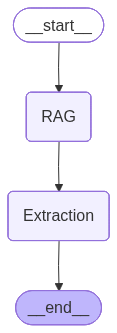

In [7]:
extraction_app

In [8]:
raw_data.head(3)

,Post_ID,Type,Body,Date,URL
0,7eon9l,Comment,It is normal that there isn't a place to chat?,2022-01-21 03:54:04,https://www.reddit.com/r/laptops/comments/7eon...
1,7eon9l,Comment,How do i get the verify button? It doesn't apper.,2021-11-22 10:14:07,https://www.reddit.com/r/laptops/comments/7eon...
2,7eon9l,Comment,Any recommendations for laptops mainly for onl...,2022-03-17 10:25:31,https://www.reddit.com/r/laptops/comments/7eon...


In [9]:
# ==========================================
# 6. Execution
# ==========================================

# ── Phase 1: Tagging (행별 처리, 기존과 동일) ──
tagging_results = []

for i, review in enumerate(tqdm(raw_data['Body'], desc="[Phase 1] Tagging")):
    try:
        final_state = tagging_app.invoke({"raw_review": review})
        tagging_results.append({
            "Index":           i,
            "Original_Review": review,
            "Is_Valid":        final_state.get("is_valid", False),
            "Purpose":         final_state.get("primary_purpose", "None"),
            "Reasoning":       final_state.get("reasoning", ""),
            "Designer_Action": final_state.get("designer_action", ""),
            "Evidence":        final_state.get("evidence_snippet", "")
        })
    except Exception as e:
        print(f"\n[Error] 인덱스 {i} 처리 중 중단: {e}")
        tagging_results.append({
            "Index": i, "Original_Review": review,
            "Is_Valid": False, "Purpose": "None",
            "Reasoning": f"Error: {e}",
            "Designer_Action": "", "Evidence": ""
        })

tagging_df = pd.DataFrame(tagging_results)

print("\n[Phase 1 완료] Purpose 분포:")
print(tagging_df[tagging_df['Is_Valid'] == True]['Purpose'].value_counts())

[Phase 1] Tagging:   0%|          | 0/5000 [00:00<?, ?it/s]


--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---


[Phase 1] Tagging:   0%|          | 1/5000 [00:01<2:15:19,  1.62s/it]


--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---


[Phase 1] Tagging:   0%|          | 2/5000 [00:03<2:28:38,  1.78s/it]

...


--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---


[Phase 1] Tagging: 100%|█████████▉| 4999/5000 [2:02:52<00:01,  1.44s/it]


--- [에이전트: Auditor/Tagger] 리뷰 분석 시작 ---


[Phase 1] Tagging: 100%|██████████| 5000/5000 [2:02:53<00:00,  1.47s/it]


[Phase 1 완료] Purpose 분포:
Purpose
Casual          322
Professional    254
None             34
Name: count, dtype: int64


In [13]:
# ── Phase 2: CR Extraction (Purpose별 배치 처리) ──
cr_results = {purpose: [] for purpose in PURPOSES}

for purpose in PURPOSES:
    segment_df = tagging_df[
        (tagging_df["Is_Valid"] == True) &
        (tagging_df["Purpose"] == purpose)
    ].reset_index(drop=True)

    total = len(segment_df)
    print(f"\n[Phase 2] {purpose} 세그먼트: {total}개 리뷰")

    if total == 0:
        print(f"  → valid 리뷰 없음, 스킵")
        continue

    num_batches = (total + BATCH_SIZE - 1) // BATCH_SIZE

    for batch_idx in tqdm(range(num_batches), desc=f"{purpose} 배치"):
        start = batch_idx * BATCH_SIZE
        end   = min(start + BATCH_SIZE, total)
        batch = segment_df.iloc[start:end]

        final_state = extraction_app.invoke({
            "purpose":             purpose,
            "reviews":             batch["Original_Review"].tolist(),
            "designer_actions":    batch["Designer_Action"].tolist(),
            "existing_knowledge":  "",
            "extracted_crs":       [],
            "cr_inventory":        []
        })

        batch_crs = final_state.get("extracted_crs", [])
        for cr in batch_crs:
            cr["purpose"]     = purpose
            cr["batch_idx"]   = batch_idx
            cr["batch_range"] = f"{start}~{end-1}"

        cr_results[purpose].extend(batch_crs)

    print(f"  → {purpose} 완료: 총 {len(cr_results[purpose])}개 CR")

print("\n[Phase 2 완료]")
for p, crs in cr_results.items():
    print(f"  {p}: {len(crs)}개")


[Phase 2] Professional 세그먼트: 254개 리뷰


Professional 배치:   0%|          | 0/6 [00:00<?, ?it/s]

--- [에이전트: Extractor] Professional / 50개 리뷰 배치 분석 ---


Professional 배치:  17%|█▋        | 1/6 [00:11<00:58, 11.69s/it]

>>> [Memory/Professional] 3개 신규 CR 등록
--- [에이전트: Extractor] Professional / 50개 리뷰 배치 분석 ---


...

>>> [Memory/Casual] 5개 신규 CR 등록
--- [에이전트: Extractor] Casual / 50개 리뷰 배치 분석 ---


Casual 배치:  86%|████████▌ | 6/7 [00:40<00:06,  6.93s/it]

>>> [Memory/Casual] 5개 신규 CR 등록
--- [에이전트: Extractor] Casual / 22개 리뷰 배치 분석 ---


Casual 배치: 100%|██████████| 7/7 [00:46<00:00,  6.60s/it]

>>> [Memory/Casual] 6개 신규 CR 등록
  → Casual 완료: 총 56개 CR

[Phase 2 완료]
  Professional: 48개
  Casual: 56개


In [12]:
tagging_df.head(10)

,Index,Original_Review,Is_Valid,Purpose,Reasoning,Designer_Action,Evidence
0,0,It is normal that there isn't a place to chat?,False,None,The review is a question about missing chat fu...,,It is normal that there isn't a place to chat?
1,1,How do i get the verify button? It doesn't apper.,False,None,The text is a help request about a missing but...,,How do i get the verify button? It doesn't apper.
2,2,Any recommendations for laptops mainly for onl...,False,None,"This is a request for purchase advice, not act...",,Any recommendations for laptops mainly for onl...
3,3,I found a lenovo gaming laptop with a 3060 GPU...,False,None,This is a help-seeking question about whether ...,,
4,4,Alright I have narrowed it down to TWO laptops...,False,None,This is a pre-purchase advice request with no ...,,I am leaning towards the ACER but I want some ...
5,5,I had an option to buy 3050 ti with 17 11thgen...,False,None,The text is a question asking for purchase val...,,
6,6,I’m looking for a laptop in the $500-$700 rang...,False,None,"This is a pre-purchase advice question, not fe...",,“I’ve looked at some gaming laptops but wasn’t...
7,7,Hello\nhttps://www.unieuro.it/online/Notebook/...,False,None,The text is a help-seeking question asking if ...,,
8,8,[deleted],False,None,The content '[deleted]' is not a self-containe...,,
9,9,"Hello, seeing if anyone can help with my issue...",False,None,The text is a help request about a BIOS/passwo...,,


In [14]:
# ==========================================
# 7. 결과 저장
# ==========================================

# Phase 1: Tagging 결과
tagging_df.to_excel(
    '../Data/Preprocessed_data/reddit_reviews_tagged_agent_driven_03.xlsx',
    index=False
)

In [15]:
# Phase 2: CR Extraction 결과 (Purpose별 시트 분리)
cr_output_path = '../Data/CR_Extraction/agent_driven_cr_extraction_05.xlsx'
with pd.ExcelWriter(cr_output_path, engine='openpyxl') as writer:
    for purpose, crs in cr_results.items():
        if crs:
            cr_df = pd.DataFrame(crs)
            if "supporting_reviews" in cr_df.columns:
                cr_df["supporting_reviews"] = cr_df["supporting_reviews"].apply(
                    lambda x: ", ".join(x) if isinstance(x, list) else str(x)
                )
            cr_df.to_excel(writer, sheet_name=purpose, index=False)

print(f"저장 완료: {cr_output_path}")

저장 완료: ../Data/CR_Extraction/agent_driven_cr_extraction_05.xlsx


In [16]:
# ChromaDB 확인
for purpose in PURPOSES:
    print(f"chroma_db_{purpose.lower()}: {os.path.exists(f'./chroma_db_{purpose.lower()}')}")

chroma_db_professional: True
chroma_db_casual: True


In [17]:
# ==========================================
# 8. Phase 3 - CR Consolidation
#    배치 간 중복 CR을 LLM으로 최종 통합
#    목표: 세그먼트당 10~15개로 압축
# ==========================================

CONSOLIDATION_PROMPT = """
### Role: QFD Data Curator
You will receive a raw list of Customer Requirements (CRs) extracted
from multiple review batches for the "{purpose}" user segment.
Some CRs may be duplicates or near-duplicates across batches.

### Task:
1. **Merge duplicates**: If two or more CRs represent the same need,
   merge them into one canonical noun-phrase term.
   Use the most concise and standard phrasing.
2. **Keep distincts**: If two CRs represent genuinely different needs, keep both.
3. **Count Limit**: The final list must contain 10 to 15 CRs maximum.
   If you have more, keep only the most representative ones.
   Prioritize CRs that were mentioned across multiple batches.

### Output Schema (JSON only):
{{
    "consolidated_crs": [
        {{
            "requirement": "Final canonical noun-phrase label",
            "merged_from": ["original CR 1", "original CR 2"],
            "evidence_summary": "Aggregated summary"
        }}
    ]
}}
"""


def consolidate_crs(purpose: str, raw_crs: list) -> list:
    if not raw_crs:
        return []

    cr_list_text = "\n".join(
        [f"- {cr['requirement']}" for cr in raw_crs]
    )

    try:
        response = llm.invoke([
            SystemMessage(content=CONSOLIDATION_PROMPT.format(purpose=purpose)),
            HumanMessage(content=f"Raw CR list:\n{cr_list_text}")
        ])
        result = json.loads(
            response.content.replace("```json", "").replace("```", "").strip()
        )
        consolidated = result.get("consolidated_crs", [])
        for cr in consolidated:
            cr["purpose"] = purpose
        return consolidated
    except Exception as e:
        print(f"[Consolidation Error / {purpose}] {e}")
        return raw_crs


# 실행
consolidated_results = {}

for purpose in PURPOSES:
    raw_count = len(cr_results[purpose])
    print(f"[Phase 3] {purpose}: {raw_count}개 → 통합 중...")
    consolidated_results[purpose] = consolidate_crs(purpose, cr_results[purpose])
    print(f"  → {len(consolidated_results[purpose])}개로 정리")

# 저장
consolidated_path = '../Data/CR_Extraction/phase3_cr_consolidated_v3.xlsx'
with pd.ExcelWriter(consolidated_path, engine='openpyxl') as writer:
    for purpose, crs in consolidated_results.items():
        if crs:
            df = pd.DataFrame(crs)
            if "merged_from" in df.columns:
                df["merged_from"] = df["merged_from"].apply(
                    lambda x: ", ".join(x) if isinstance(x, list) else str(x)
                )
            df.to_excel(writer, sheet_name=purpose, index=False)

print(f"\n저장 완료: {consolidated_path}")

[Phase 3] Professional: 48개 → 통합 중...
  → 14개로 정리
[Phase 3] Casual: 56개 → 통합 중...
  → 15개로 정리

저장 완료: ../Data/CR_Extraction/phase3_cr_consolidated_v3.xlsx


In [18]:
# 최종 결과 확인 (Consolidation 기준)
for purpose, crs in consolidated_results.items():
    print(f"\n{'='*40}")
    print(f"  {purpose} ({len(crs)}개 CR)")
    print(f"{'='*40}")
    for i, cr in enumerate(crs, 1):
        print(f"  [{i:02d}] {cr['requirement']}")
        if cr.get('evidence_summary'):
            print(f"       └ {cr['evidence_summary'][:80]}")


  Professional (14개 CR)
  [01] Extended all-day battery life
       └ Repeated emphasis on long-lasting battery that comfortably covers a full day of 
  [02] Baseline 16GB RAM with competent CPU for professional workloads
       └ Multiple mentions specify 16GB RAM as the base with a solid CPU as the minimum f
  [03] High RAM capacity and easy memory upgradability
       └ Users want support for large memory configurations (at least 32GB) plus either u
  [04] Well-balanced CPU-centric performance for professional tasks
       └ Professionals seek a strong, balanced CPU configuration optimized for coding and
  [05] Above-minimum specs for demanding creative and bloat-tolerant workloads
       └ Repeated requirement for headroom beyond basic specs to comfortably handle creat
  [06] Stable thermal management under sustained and gaming loads
       └ Thermals must maintain performance over long sessions (work or occasional gaming
  [07] High build quality comparable to MacBook-class devic

In [19]:
_d_01 = pd.read_excel('../Data/Preprocessed_data/reddit_reviews_tagged_agent_driven_02.xlsx')
_d_02 = pd.read_excel('../Data/Preprocessed_data/reddit_reviews_tagged_agent_driven_03.xlsx')

In [21]:
_d_01[_d_01['Is_Valid'] == True]['Purpose'].value_counts()

Purpose
Casual          60
Professional    50
Name: count, dtype: int64

In [22]:
_d_02[_d_02['Is_Valid'] == True]['Purpose'].value_counts()

Purpose
Casual          322
Professional    254
Name: count, dtype: int64